# Exploratory Data Analysis Starter

## Import packages

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [ ]:
client_df = pd.read_csv("/content/client_data (1).csv")
price_df = pd.read_csv('/content/price_data (1).csv')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [ ]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,15/06/2013,15/06/2016,01/11/2015,23/06/2015,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,21/08/2009,30/08/2016,21/08/2009,31/08/2015,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,16/04/2010,16/04/2016,16/04/2010,17/04/2015,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [ ]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,01/01/2015,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,01/02/2015,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,01/03/2015,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [ ]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  int64  
 12  forecast_meter_rent_12m         

In [ ]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [ ]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [ ]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


In [ ]:
statistical_col_1=client_df.select_dtypes(include="number")
for col in statistical_col_1:
  print(col)
  print("max:",client_df[col].max())
  print("min:",client_df[col].min())
  print("mean:",client_df[col].mean())


cons_12m
max: 6207104
min: 0
mean: 159220.2862522251
cons_gas_12m
max: 4154590
min: 0
mean: 28092.375325208817
cons_last_month
max: 771203
min: 0
mean: 16090.269752156648
forecast_cons_12m
max: 82902.83
min: 0.0
mean: 1868.6148795015747
forecast_cons_year
max: 175375
min: 0
mean: 1399.7629056552103
forecast_discount_energy
max: 30
min: 0
mean: 0.9667260030124606
forecast_meter_rent_12m
max: 599.31
min: 0.0
mean: 63.08687114884294
forecast_price_energy_off_peak
max: 0.273963
min: 0.0
mean: 0.1372832656853348
forecast_price_energy_peak
max: 0.195975
min: 0.0
mean: 0.05049076721895111
forecast_price_pow_off_peak
max: 59.26637796
min: 0.0
mean: 43.13005552529372
imp_cons
max: 15042.79
min: 0.0
mean: 152.7868957962481
margin_gross_pow_ele
max: 374.64
min: 0.0
mean: 24.56512118307545
margin_net_pow_ele
max: 374.64
min: 0.0
mean: 24.562517458578668
nb_prod_act
max: 32
min: 1
mean: 1.2923456113925784
net_margin
max: 24570.65
min: 0.0
mean: 189.26452211419968
num_years_antig
max: 13
min: 1
mean

In [ ]:
statistical_col_2=price_df.select_dtypes(include="number")
for col in statistical_col_2:
  print(col)
  print("max:",price_df[col].max())
  print("min:",price_df[col].min())
  print("mean:",price_df[col].mean())

price_off_peak_var
max: 0.2807
min: 0.0
mean: 0.14102697259505087
price_peak_var
max: 0.229788
min: 0.0
mean: 0.05463039689873681
price_mid_peak_var
max: 0.114102
min: 0.0
mean: 0.03049600745893825
price_off_peak_fix
max: 59.44470996
min: 0.0
mean: 43.33447695717784
price_peak_fix
max: 36.490692
min: 0.0
mean: 10.622875247557124
price_mid_peak_fix
max: 17.45822136
min: 0.0
mean: 6.409984354197781


In [ ]:
client_df["has_gas"].value_counts()

,count
has_gas,
f,11955
t,2651


In [ ]:
client_df["has_gas"]=client_df["has_gas"].replace({"f":0,"t":1})

<ipython-input-13-f882ac20e112>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  client_df["has_gas"]=client_df["has_gas"].replace({"f":0,"t":1})


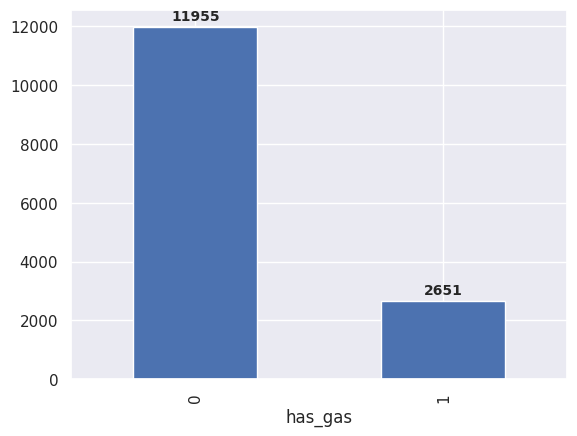

In [ ]:
ax=client_df["has_gas"].value_counts().plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10, fontweight='bold')

plt.show()

Only 18.15% of clients are gas clients also.

In [ ]:
gas_client_percent=(2651/14606)
gas_client_percent*100

18.150075311515813

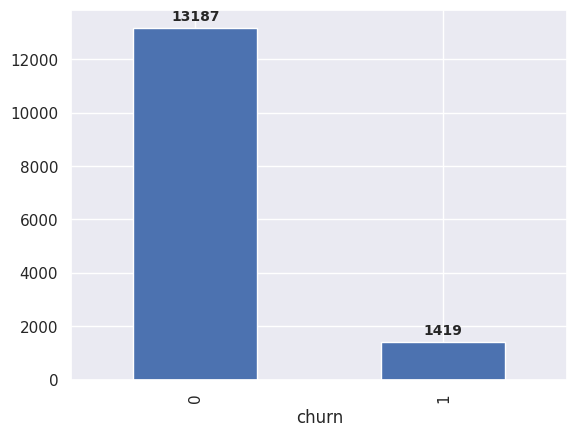

In [ ]:
ax=client_df["churn"].value_counts().plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10, fontweight='bold')

plt.show()

The client churn rate is approximately 9.71%

In [ ]:
client_churn_percent=(1419/14606)
client_churn_percent*100

9.715185540188962

In [ ]:
col=client_df.columns
for col in col:
  print(col,":",client_df[col].value_counts())

id : id
563dde550fd624d7352f3de77c0cdfcd    1
24011ae4ebbe3035111d65fa7c15bc57    1
d29c2c54acc38ff3c0614d0a653813dd    1
764c75f661154dac3a6c254cd082ea7d    1
bba03439a292a1e166f80264c16191cb    1
                                   ..
f2b93783adecf0d0d8d60ab547bda3de    1
4e4a34a6d91ff25d0fdf68733907ad44    1
bd14bbac3aca710ee5288fcd8511d4bb    1
e4773b60d2e68aac94795782abfc006b    1
c5037389dd8be351d3c40f2973da2391    1
Name: count, Length: 14606, dtype: int64
channel_sales : channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64
cons_12m : cons_12m
0          117
2882597     27
3329244     24
1743025     18
6207104     18
          ... 
17292        1
15966        1
26024    

In [ ]:
client_df=client_df.replace({"MISSING":np.nan})

In [ ]:
col=price_df.columns
for col in col:
  print(col,":",price_df[col].value_counts())

id : id
c18b6305122e4976739b8420d5b54ec5    12
e4053a0ad6c55e4665e8e9adb9f75db5    12
1221993f581c1b335d231e247028d40d    12
2dc2c9a9f6e6896d9a07d7bcbb9d0ce9    12
762cab733464cae4ce1d452ce84cb94b    12
                                    ..
3e459d61dc831e29f8a9a9a59f95efd2     8
223a98d3832ece78cbf279a194868b54     8
c5dcd5c506e565aaabffa29bc1ec0a37     7
15b36e47cf04bf151e3f4438d12672e5     7
bf89f2d8c1b133a134fd93603cb4c947     7
Name: count, Length: 16096, dtype: int64
price_date : price_date
01/12/2015    16094
01/08/2015    16094
01/07/2015    16090
01/11/2015    16087
01/10/2015    16085
01/06/2015    16085
01/09/2015    16082
01/02/2015    16082
01/05/2015    16080
01/04/2015    16079
01/03/2015    16074
01/01/2015    16070
Name: count, dtype: int64
price_off_peak_var : price_off_peak_var
0.152445    6291
0.151367    5652
0.125976    5139
0.127566    4373
0.147600    4285
            ... 
0.104487       1
0.138282       1
0.167023       1
0.200112       1
0.121509       1
Name:

In [ ]:
client_df["channel_sales"] = client_df["channel_sales"].fillna(client_df["channel_sales"].mode()[0])
client_df["origin_up"]= client_df["origin_up"].fillna(client_df["origin_up"].mode()[0])

---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations.

In [ ]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

Thhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

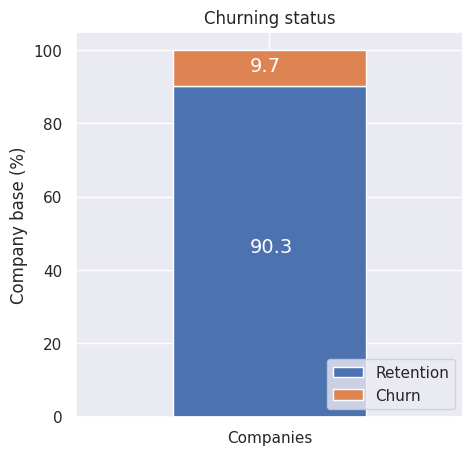

In [ ]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

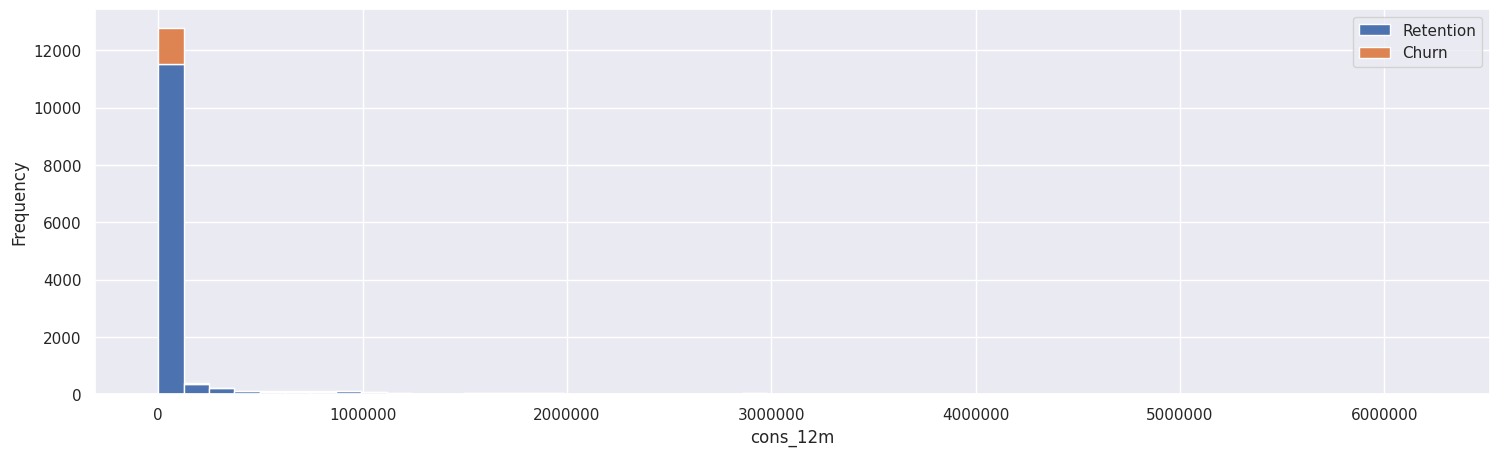

In [ ]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

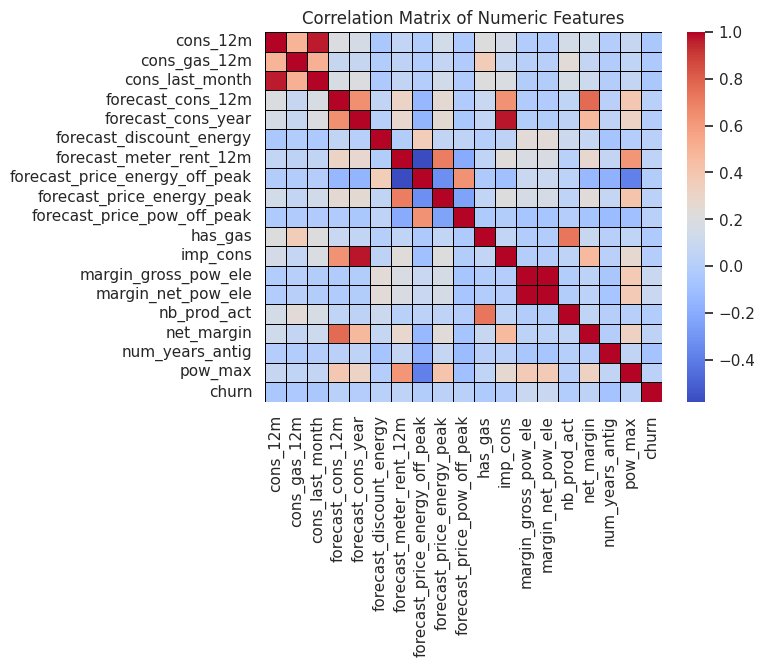

In [ ]:
correlation_matrix = client_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,  cmap="coolwarm",linewidths=0.5,linecolor="black")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


In [ ]:
correlation_matrix

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
cons_12m,1.000000,0.488474,0.968212,0.193947,0.167093,-0.043282,0.065268,-0.007748,0.145908,-0.026566,0.212973,0.159711,-0.011926,-0.011905,0.154251,0.133614,-0.003565,0.082889,-0.045968
cons_gas_12m,0.488474,1.000000,0.507007,0.084359,0.080934,-0.012595,0.041393,-0.017684,0.074002,-0.020558,0.359679,0.077846,0.006868,0.006852,0.239387,0.070867,-0.013815,0.054317,-0.037957
cons_last_month,0.968212,0.507007,1.000000,0.177773,0.193574,-0.040874,0.057476,-0.005187,0.136802,-0.023017,0.210662,0.187034,-0.011498,-0.011477,0.169099,0.121835,-0.003677,0.074529,-0.045284
forecast_cons_12m,0.193947,0.084359,0.177773,1.000000,0.647727,0.058435,0.305627,-0.135646,0.254056,-0.018477,0.097867,0.634600,-0.023220,-0.023231,0.055915,0.768537,0.021283,0.393946,0.012949
forecast_cons_year,0.167093,0.080934,0.193574,0.647727,1.000000,0.008518,0.276009,-0.158012,0.251005,-0.044190,0.064976,0.969395,-0.010759,-0.010727,0.040426,0.464928,0.048248,0.309647,-0.002558
forecast_discount_energy,-0.043282,-0.012595,-0.040874,0.058435,0.008518,1.000000,-0.008388,0.353735,0.059318,0.048024,0.005223,0.037939,0.241142,0.240421,0.106812,0.079784,-0.070697,-0.005032,0.017026
forecast_meter_rent_12m,0.065268,0.041393,0.057476,0.305627,0.276009,-0.008388,1.000000,-0.579353,0.706376,-0.203089,0.052873,0.224212,0.183509,0.183566,0.018109,0.275830,0.071558,0.618549,0.044245
forecast_price_energy_off_peak,-0.007748,-0.017684,-0.005187,-0.135646,-0.158012,0.353735,-0.579353,1.000000,-0.330138,0.630377,-0.032754,-0.092535,0.094498,0.094216,0.035093,-0.135107,-0.168095,-0.384397,-0.010837
forecast_price_energy_peak,0.145908,0.074002,0.136802,0.254056,0.251005,0.059318,0.706376,-0.330138,1.000000,-0.242017,0.064715,0.212317,0.165483,0.165560,0.044141,0.234942,0.080260,0.411532,0.029315
forecast_price_pow_off_peak,-0.026566,-0.020558,-0.023017,-0.018477,-0.044190,0.048024,-0.203089,0.630377,-0.242017,1.000000,-0.026138,-0.011318,-0.061869,-0.061925,-0.005335,-0.072623,-0.120136,-0.095897,0.014778


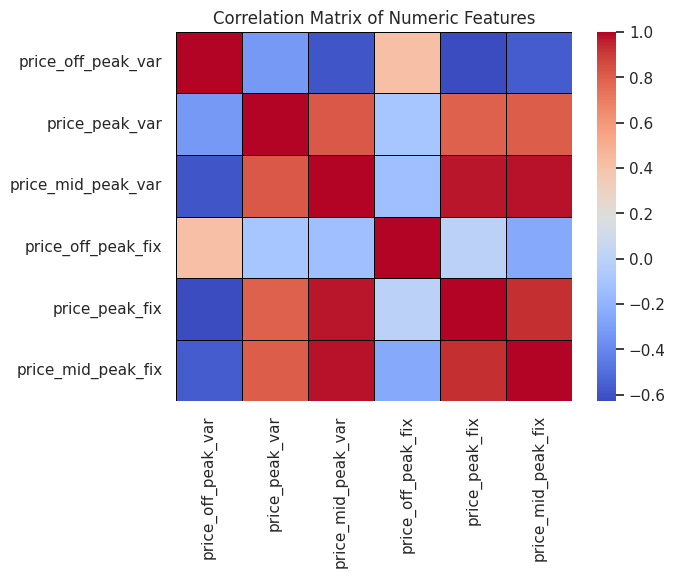

In [ ]:
correlation_matrix_2 = price_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix_2,annot=False , cmap="coolwarm",linewidths=0.5,linecolor="black")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

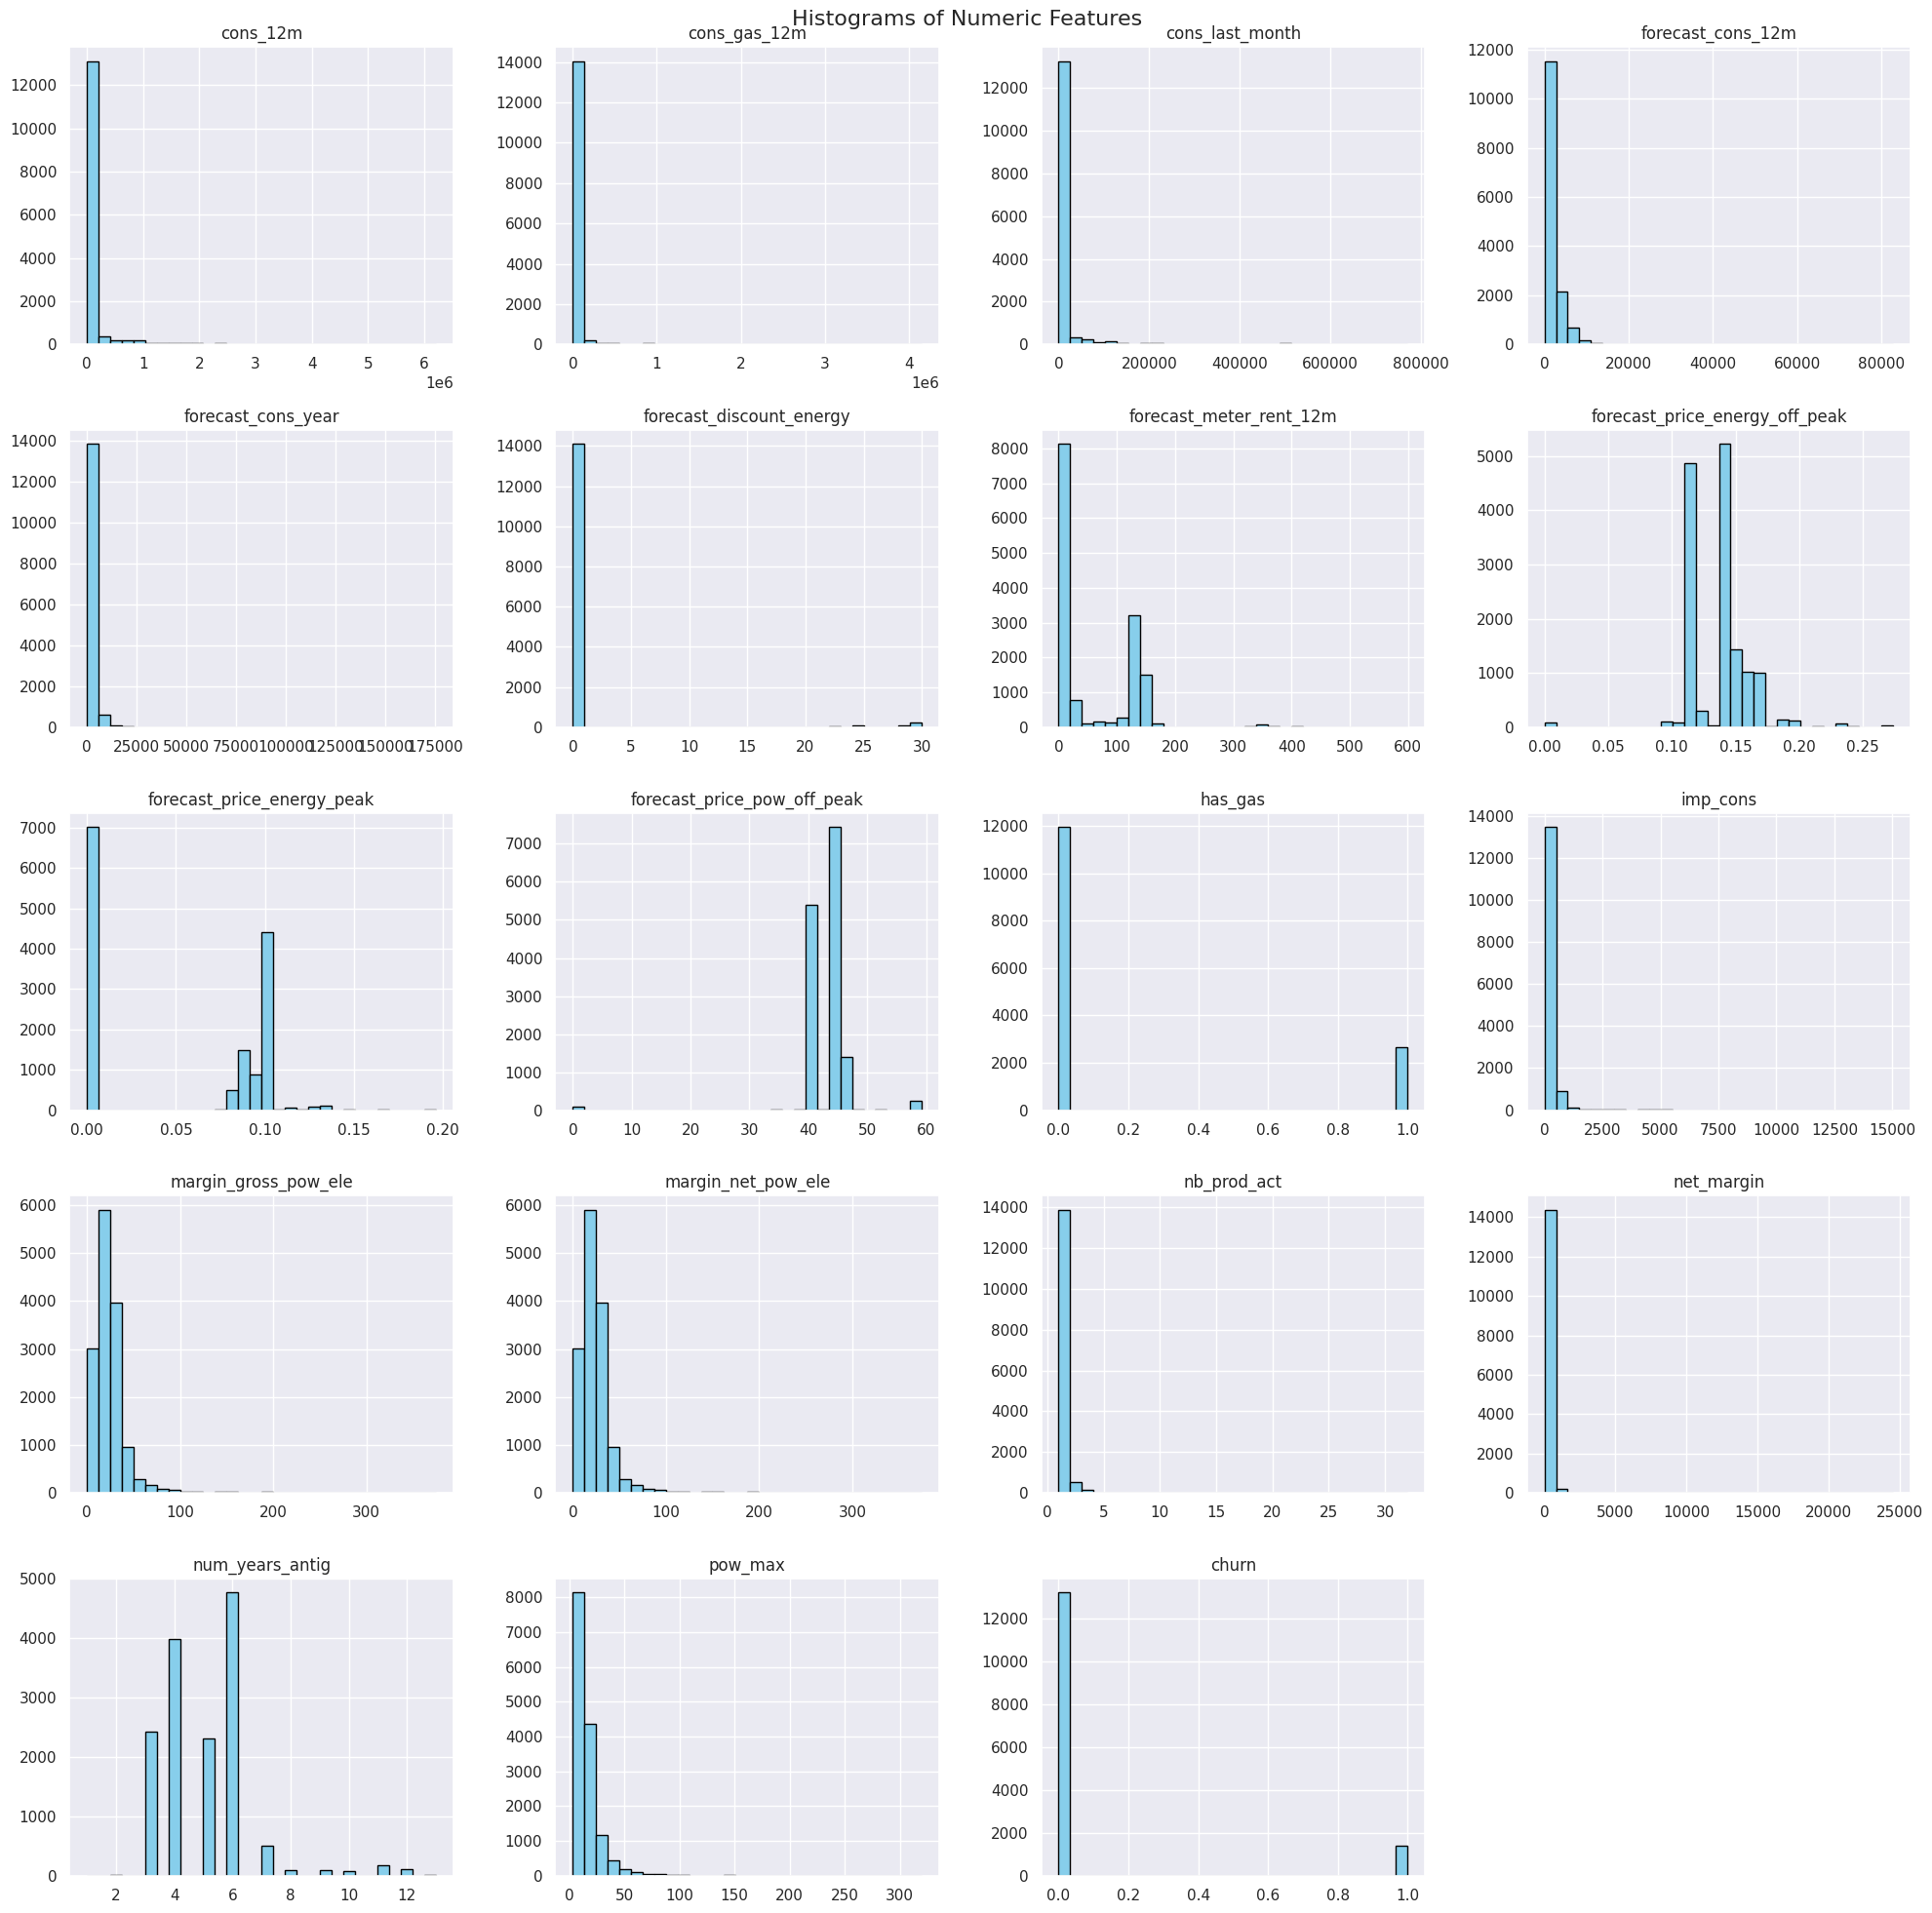

In [ ]:
client_df.hist(figsize=(20,20), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

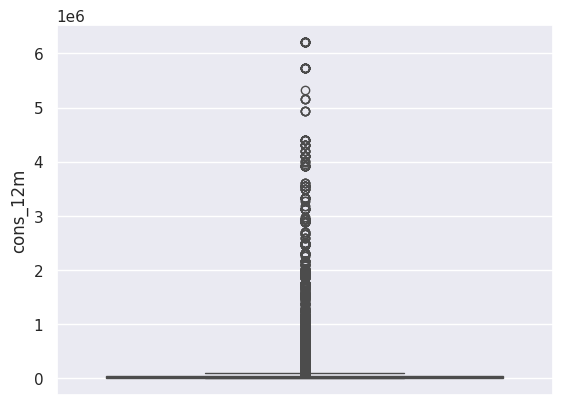

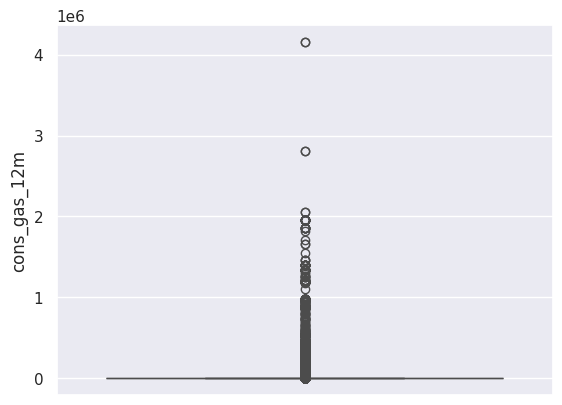

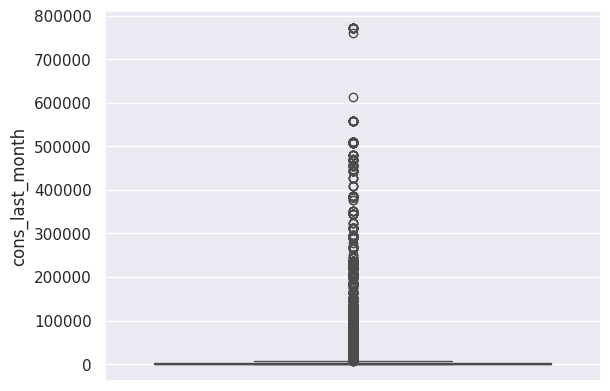

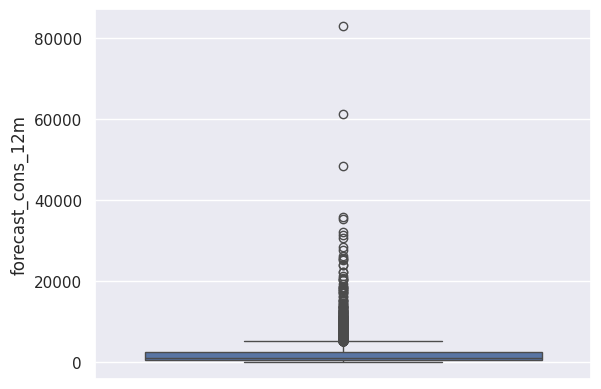

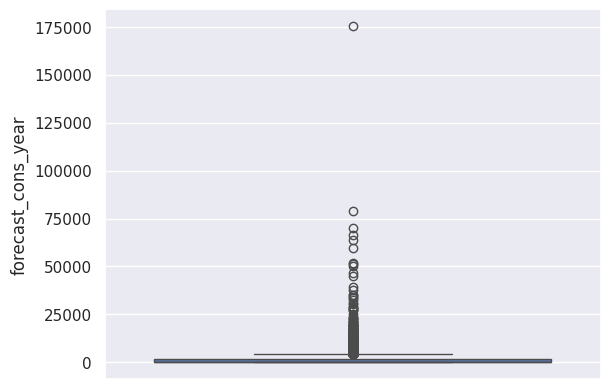

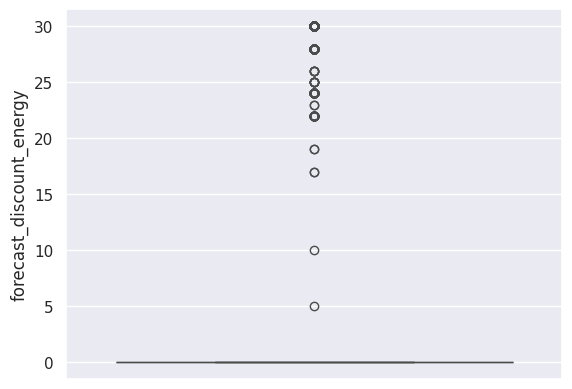

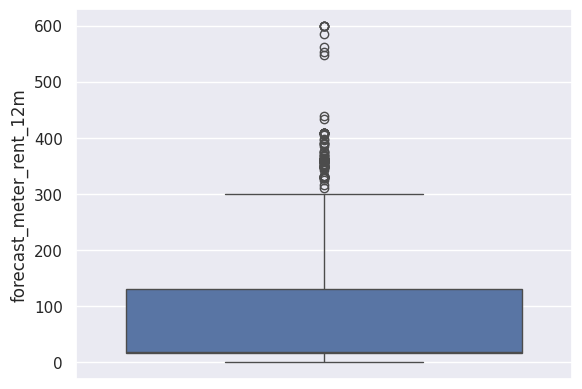

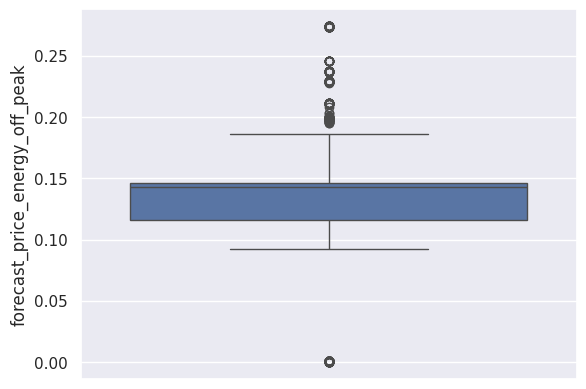

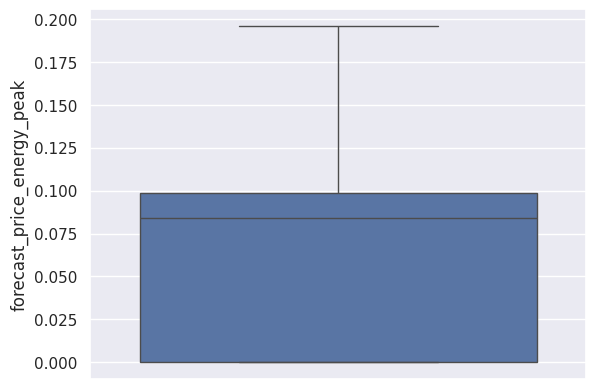

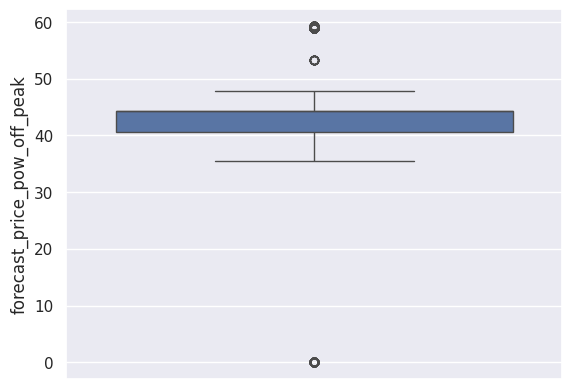

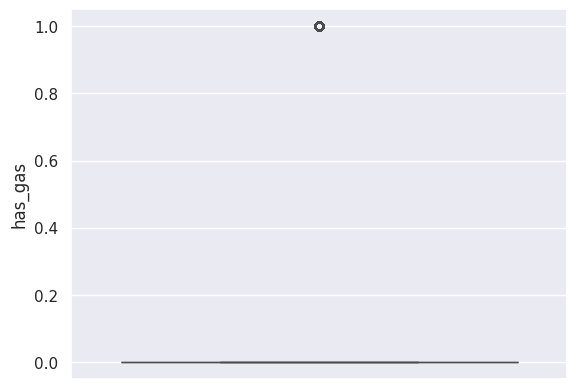

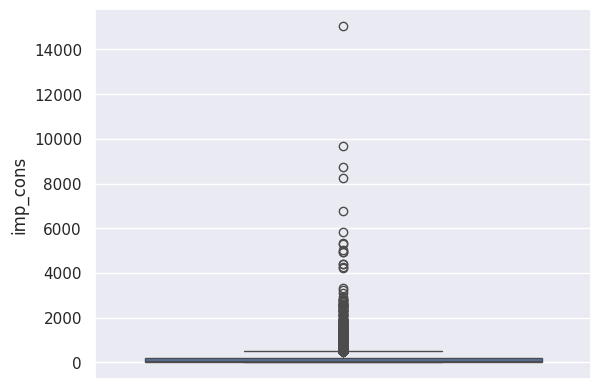

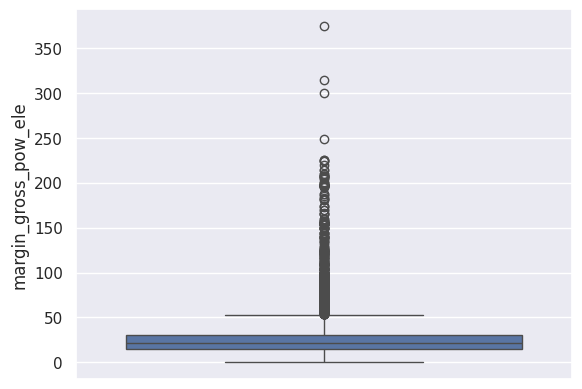

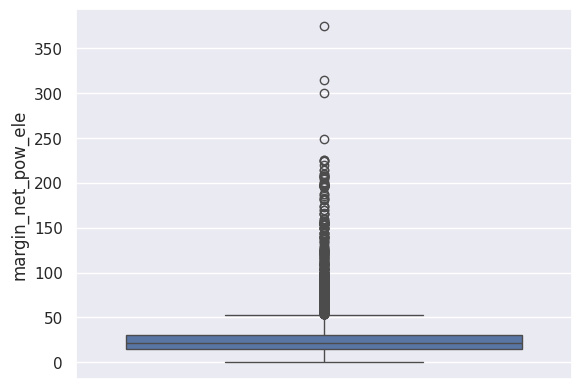

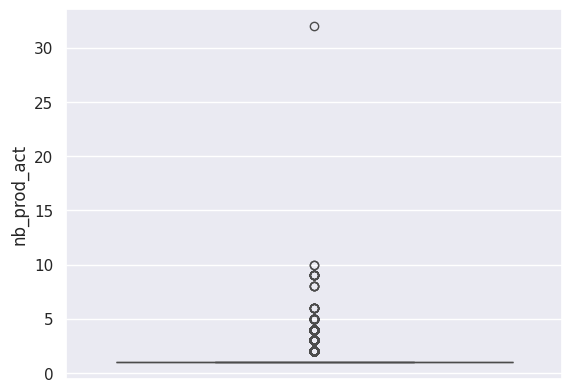

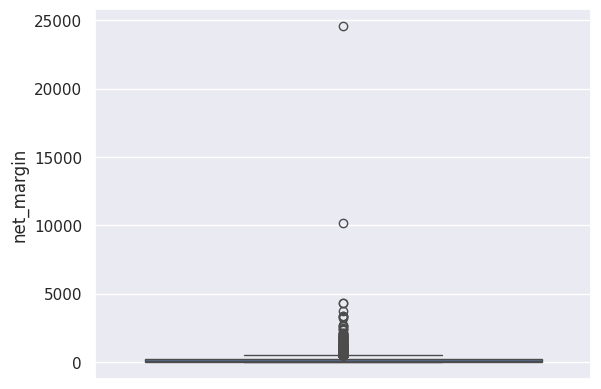

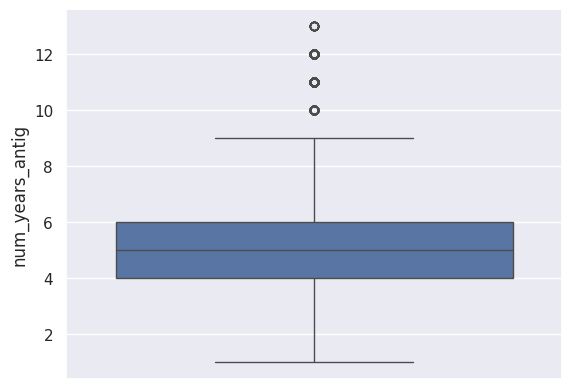

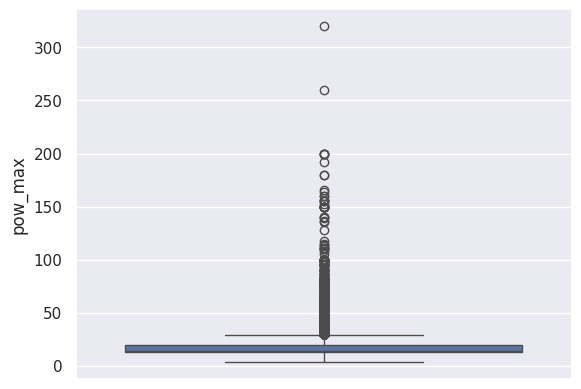

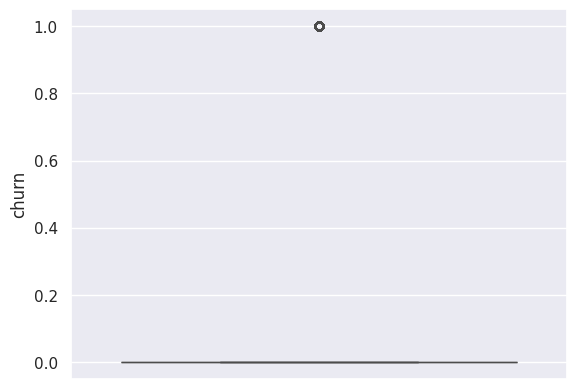

In [ ]:
numeric_cols = client_df.select_dtypes(include='number')
for col in numeric_cols:
  sns.boxplot(data=client_df,y=col)

  plt.show()


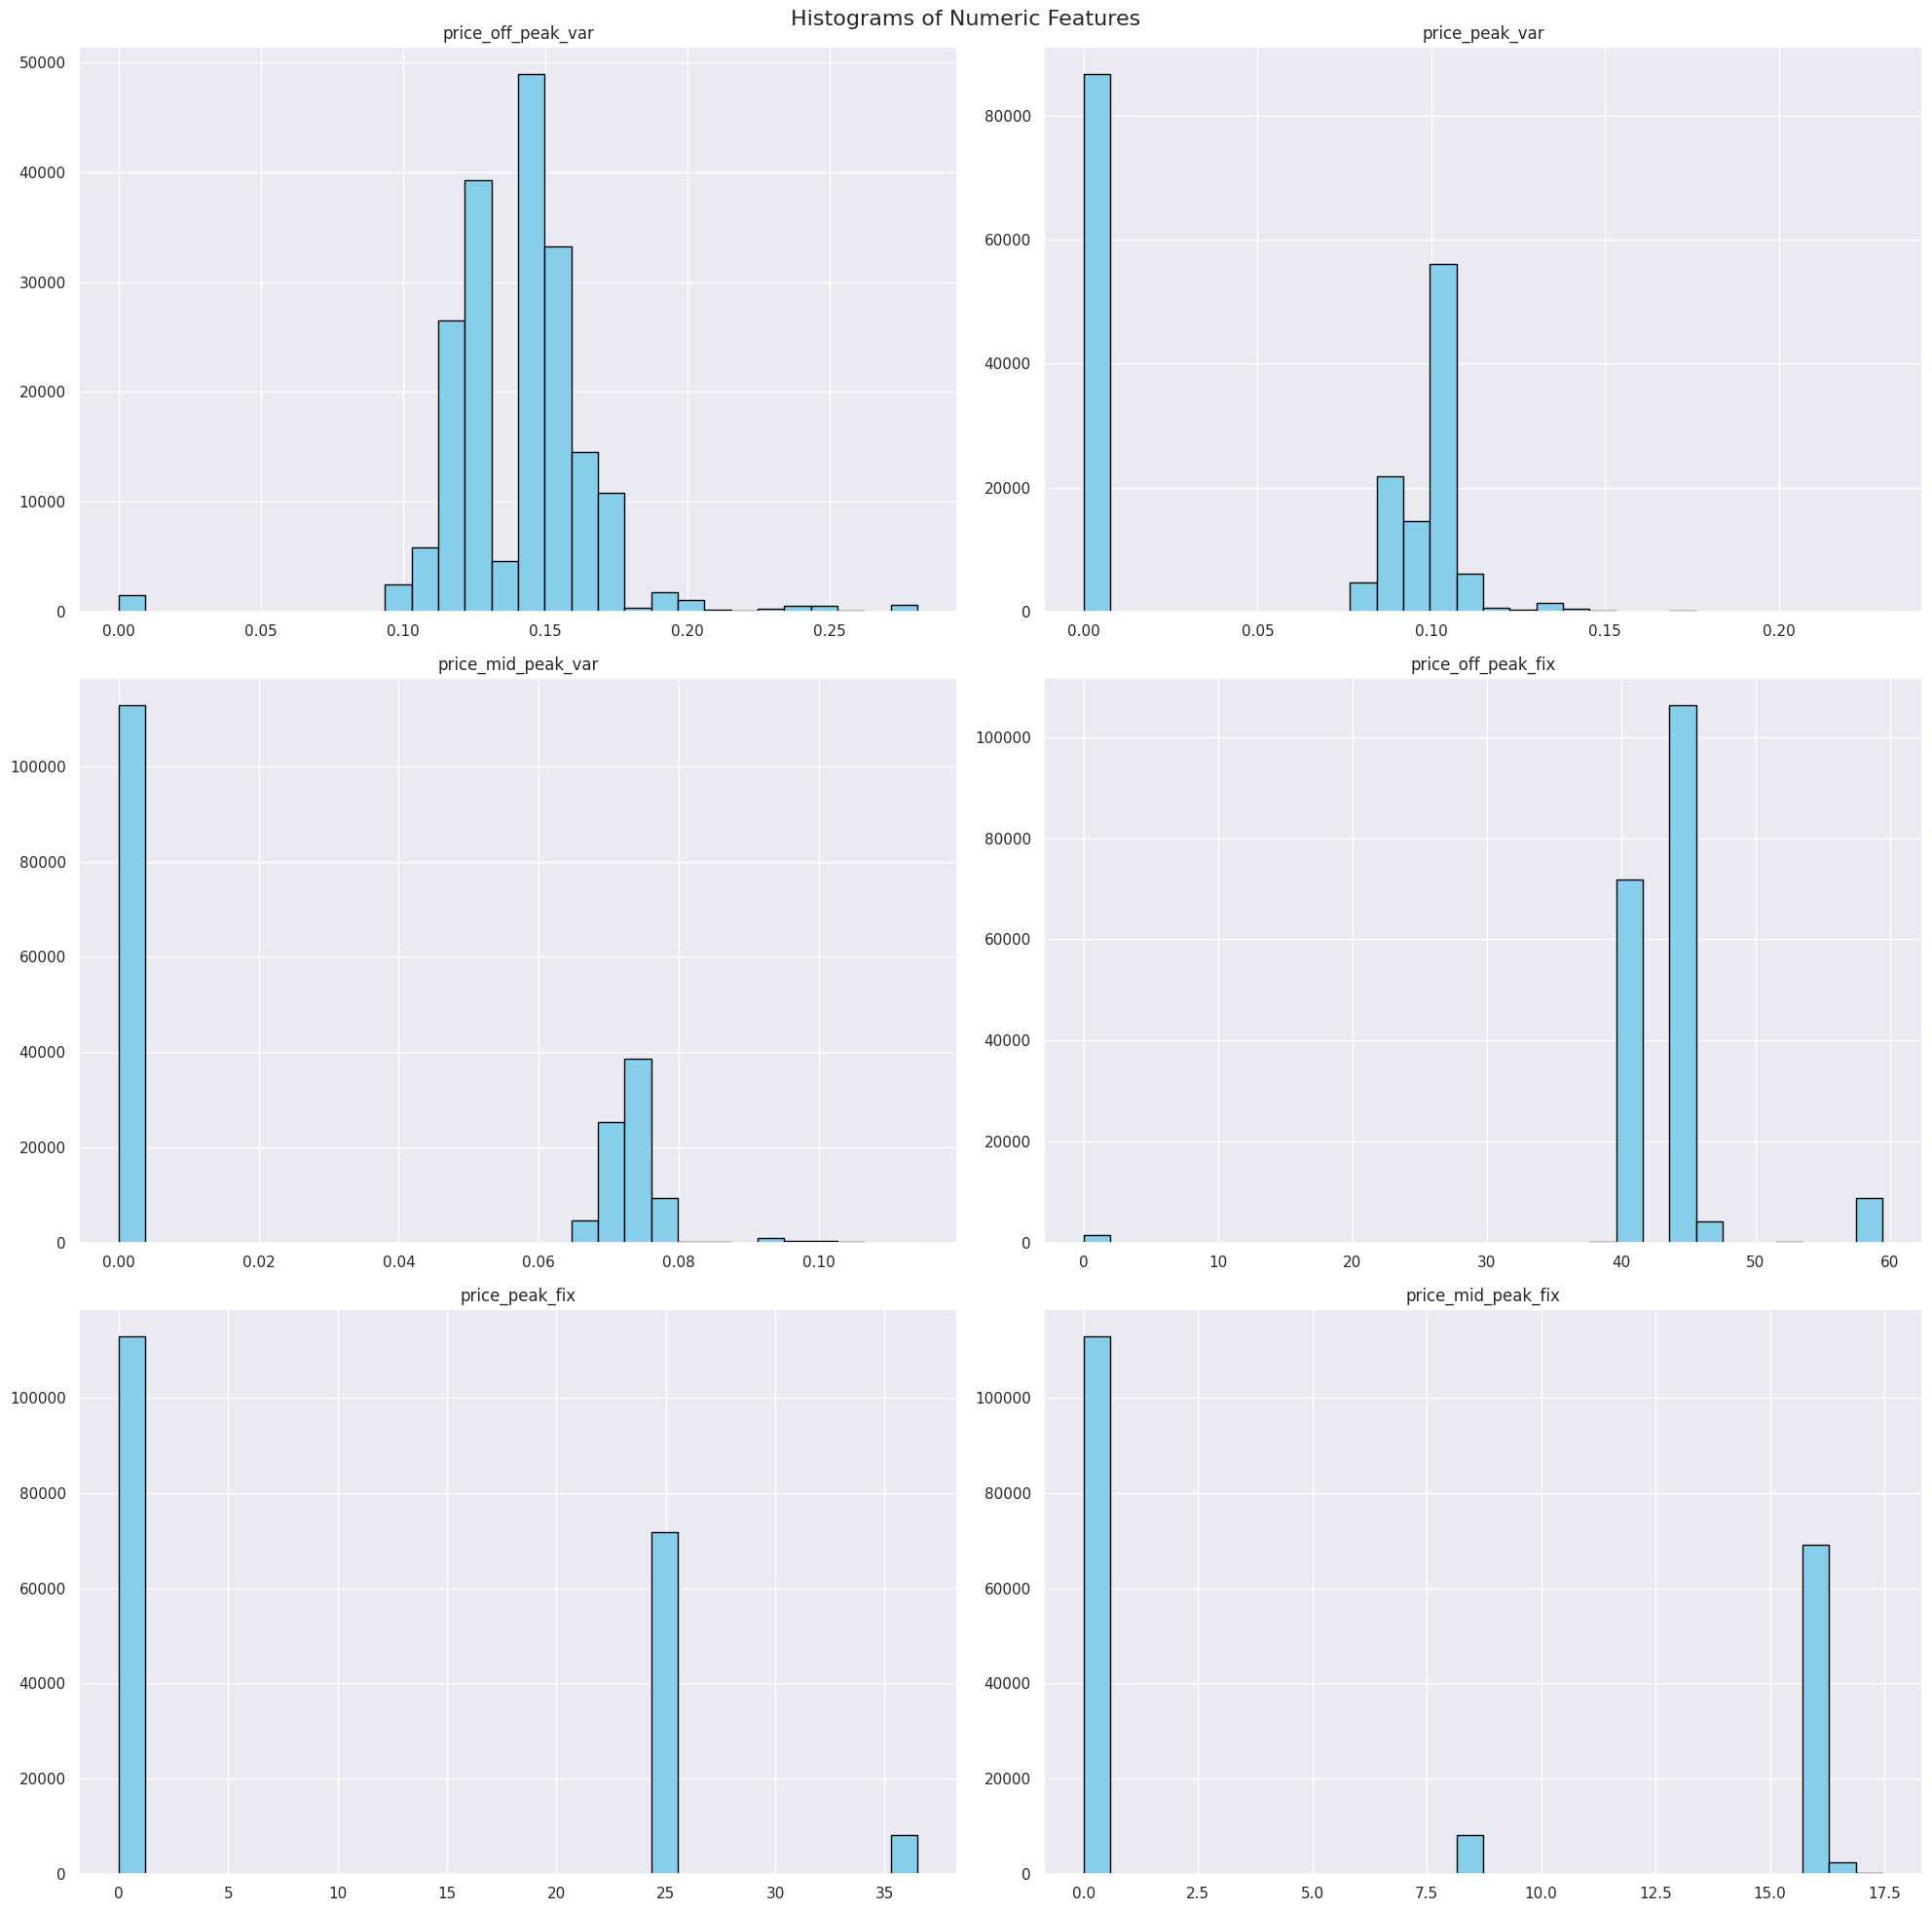

In [ ]:
price_df.hist(figsize=(20,20), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

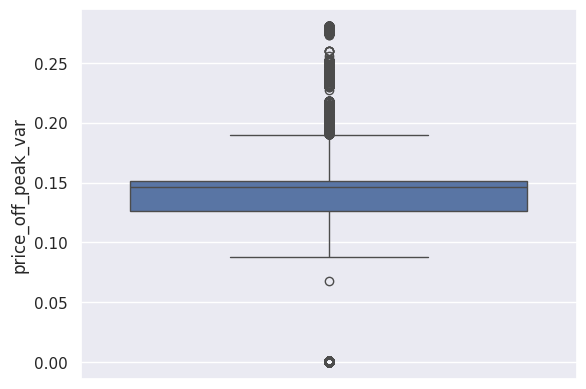

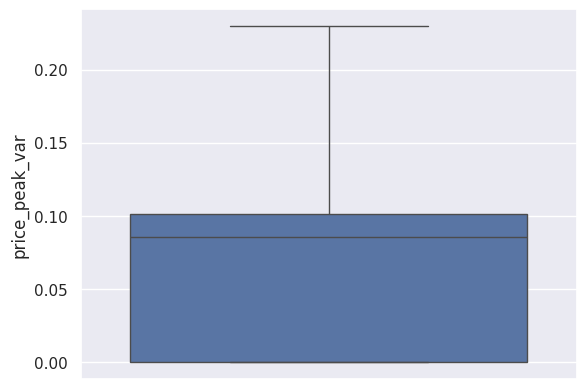

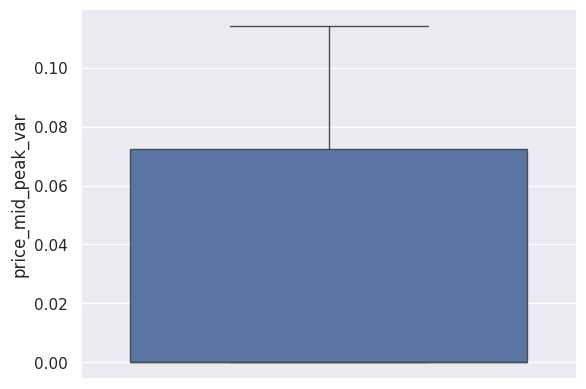

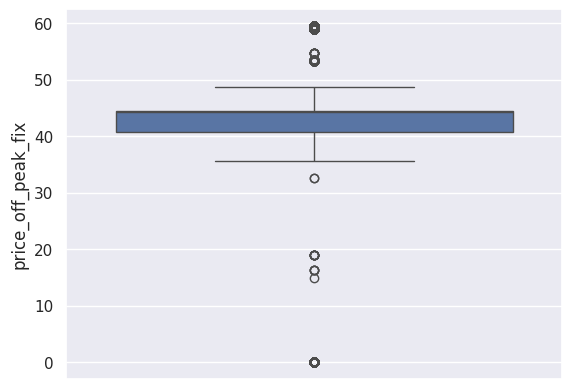

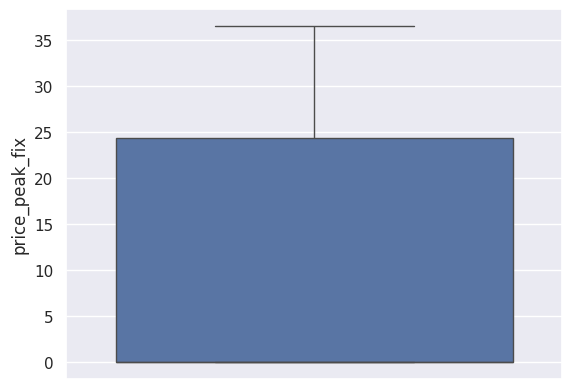

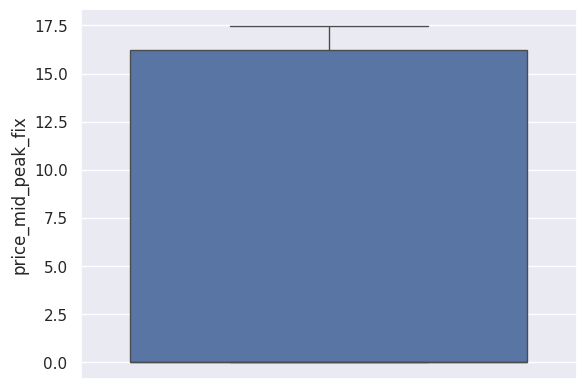

In [ ]:
numeric_cols_2 = price_df.select_dtypes(include='number')
for col in numeric_cols_2:
  sns.boxplot(data=price_df,y=col)

  plt.show()


In [ ]:
df=client_df


,date_renewal
0,23/06/2015
1,31/08/2015
2,17/04/2015
3,31/03/2015
4,09/03/2015
...,...
14601,26/05/2014
14602,28/08/2015
14603,09/02/2015
14604,31/08/2015


In [ ]:
df["date_activ"] = pd.to_datetime(df["date_activ"], dayfirst=True)
df["date_end"] = pd.to_datetime(df["date_end"],dayfirst=True )
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], dayfirst=True)
df["date_renewal"] = pd.to_datetime(df["date_renewal"], dayfirst=True)

In [ ]:
price_df["price_date"]=pd.to_datetime(price_df["price_date"],dayfirst=True)

In [ ]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id',"price_date"]).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1']-diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] =  diff['dec_2']-diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]


In [ ]:
df = pd.merge(df, diff, on='id')


In [ ]:
df["Duration"]=(((df["date_end"]-df["date_activ"]).dt.days)/365.25).astype(int)

In [ ]:
df.groupby(["num_years_antig"]).agg({'churn': 'mean'}).sort_values(by='churn', ascending=False)

,churn
num_years_antig,
2,0.272727
3,0.135224
4,0.118533
12,0.100000
5,0.086319
7,0.082515
13,0.076923
6,0.071084
11,0.064865


Companies who have been a client for less than 5 years are more likely to churn out.

In [ ]:
categorical=list(df.select_dtypes(include=["object"]).columns)
categorical

['id', 'channel_sales', 'origin_up']

In [ ]:
ohe_col=["channel_sales","origin_up"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded=ohe.fit_transform(df[ohe_col])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(ohe_col))

In [ ]:
df = pd.concat([df, encoded_df], axis=1)

In [ ]:
df=df.drop(ohe_col,axis=1)

In [ ]:
df["years_date_active_to_modification"]=((df['date_modif_prod']-df['date_activ'])/((pd.Timedelta(days=365.25)))).astype(int)
df["years_date_modification_to_end"]=((df['date_end']-df['date_modif_prod'])/((pd.Timedelta(days=365.25)))).astype(int)
df["years_date_renewal_to_end"]=((df['date_end']-df['date_renewal'])/((pd.Timedelta(days=365.25)))).astype(int)

df["years_date_modification_to_renewal"]=((df['date_renewal']-df['date_modif_prod'])/((pd.Timedelta(days=365.25)))).astype(int)



In [ ]:
df.groupby(["years_date_modification_to_renewal"]).agg({"churn":'mean'})

,churn
years_date_modification_to_renewal,
-2,0.000000
-1,0.040000
0,0.109223
1,0.105070
2,0.123130
3,0.128698
4,0.077536
5,0.068730
6,0.076159


Clients who modified the product near to the end date of contract ( 0 to 3 years) are more likely to churn

In [ ]:
df.groupby(["years_date_modification_to_end"]).agg({"churn":'mean'})

,churn
years_date_modification_to_end,
0,0.123922
1,0.105299
2,0.103165
3,0.131169
4,0.125253
5,0.071622
6,0.070523
7,0.075188
8,0.035714


Clients who modified their product very close to the contract end date are more likely to churn.

In [ ]:
df.groupby(["years_date_active_to_modification"]).agg({"churn":'mean'})

,churn
years_date_active_to_modification,
0,0.086659
1,0.133484
2,0.125729
3,0.119552
4,0.097649
5,0.075000
6,0.025641
7,0.045455
8,0.000000


Clients who modified their product within 4 years of contract activation are more likely to churn .

In [ ]:
df.groupby(["years_date_renewal_to_end"]).agg({"churn":'mean'})

,churn
years_date_renewal_to_end,
0,0.096559
1,0.116667
2,0.039216
3,0.000000


Clients who have renewed their contracts near to the end date of contract are more likely to churn.

In [ ]:
df_month_var=price_df.groupby(["id"]).agg({"price_off_peak_var": 'mean','price_peak_var': 'mean', 'price_mid_peak_var': 'mean','price_off_peak_fix': 'mean','price_peak_fix': 'mean','price_mid_peak_fix': 'mean'}).reset_index()

In [ ]:
df_month_var["off_peak_mean_diff_peak_energy"]=df_month_var["price_off_peak_var"]-df_month_var["price_peak_var"]
df_month_var["peak_mean_diff_mid_peak_energy"]=df_month_var["price_peak_var"]-df_month_var["price_mid_peak_var"]
df_month_var["off_peak_mean_diff_mid_peak_energy"]=df_month_var["price_off_peak_var"] -  df_month_var["price_mid_peak_var"]
df_month_var["off_peak_mean_diff_peak_power"]=df_month_var["price_off_peak_fix"] - df_month_var["price_peak_fix"]
df_month_var["peak_mean_diff_mid_peak_power"]=df_month_var["price_peak_fix"]  -  df_month_var["price_mid_peak_fix"]
df_month_var["off_peak_mean_diff_mid_peak_power"]=df_month_var["price_off_peak_fix"]-  df_month_var["price_mid_peak_fix"]

In [ ]:
col=["id","off_peak_mean_diff_peak_energy","peak_mean_diff_mid_peak_energy","off_peak_mean_diff_mid_peak_energy","off_peak_mean_diff_peak_power","peak_mean_diff_mid_peak_power","off_peak_mean_diff_mid_peak_power"]

In [ ]:
df = pd.merge(df, df_month_var[col], on='id')


In [ ]:
from scipy.stats import skew
num=list(df.select_dtypes(include="number").columns)

In [ ]:
num

['cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'has_gas',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'pow_max',
 'churn',
 'offpeak_diff_dec_january_energy',
 'offpeak_diff_dec_january_power',
 'Duration',
 'channel_sales_epumfxlbckeskwekxbiuasklxalciiuu',
 'channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci',
 'channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa',
 'channel_sales_foosdfpfkusacimwkcsosbicdxkicaua',
 'channel_sales_lmkebamcaaclubfxadlmueccxoimlema',
 'channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds',
 'channel_sales_usilxuppasemubllopkaafesmlibmsdf',
 'origin_up_ewxeelcelemmiwuafmddpobolfuxioce',
 'origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws',
 'origin_up_ldkssxwpmemidmecebumciepifcamkci',
 'origin_up_lxidpiddsb

In [ ]:
skewness={}
pos=[]
neg=[]
for col in num:
  skewness[col]=skew(df[col])
for key,value in skewness.items():
  if value > 0.5:
    pos.append(key)
  elif value < -0.5:
    neg.append(key)

In [ ]:
pos.remove("churn")

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df[pos+neg]= pt.fit_transform(df[pos+neg])

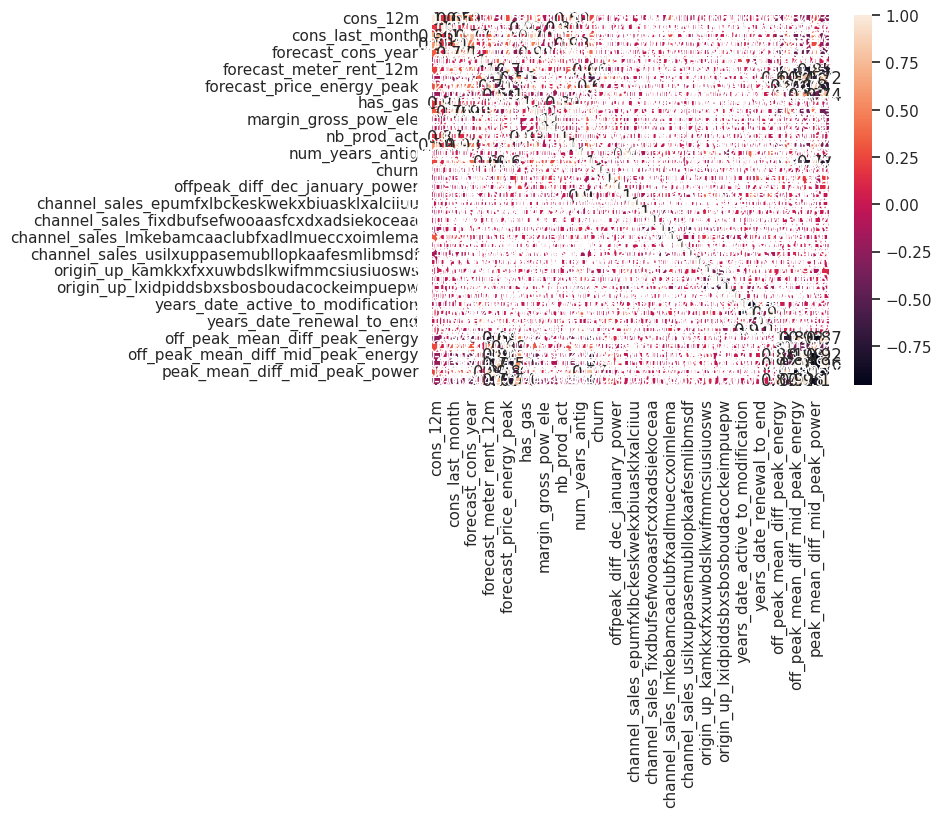

In [ ]:
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True)
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif



X = df.drop('churn', axis=1).select_dtypes(include='number')  # Only numeric features
y = df['churn']


selector = SelectKBest(score_func=f_classif, k='all')  # 'all' means score all features
selector.fit(X, y)


scores = pd.Series(selector.scores_, index=X.columns)
scores = scores.sort_values(ascending=False)



In [ ]:
df=df.drop(['date_activ'  ,'date_end', 'date_modif_prod' ,'date_renewal'],axis=1)

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 43)
(14606,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10224, 43)
(10224,)
(4382, 43)
(4382,)


In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_2 = RandomForestClassifier(
                       n_estimators=1000)
model_2.fit(X_train,y_train)

RandomForestClassifier(n_estimators=1000)

In [ ]:
y_pred_2=model_2.predict(X_test)
accuracy=accuracy_score(y_test,y_pred_2)
recall=recall_score(y_test,y_pred_2)
precision=precision_score(y_test,y_pred_2)
print(f'accuracy:{accuracy:.2f}')
print(f'recall_score:{recall:.2f}')
print(f'precision_score:{precision:.2f}')

accuracy:0.90
recall_score:0.03
precision_score:0.82


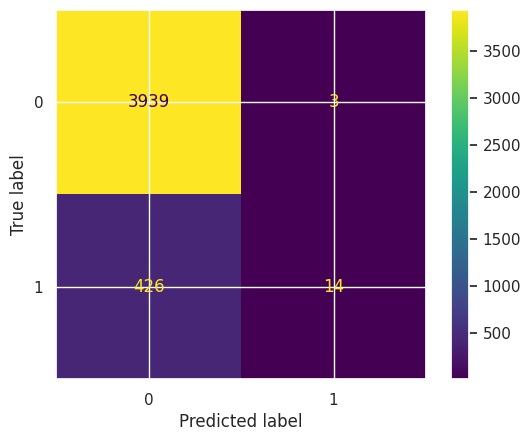

In [ ]:
cm=confusion_matrix(y_test,y_pred_2,labels=model_2.classes_)
plot=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_2.classes_)
plot.plot()
plt.show()


In [ ]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': model_2.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index()


In [ ]:
feature_importances

,index,features,importance
0,0,cons_12m,6.471393e-02
1,6,forecast_meter_rent_12m,6.275284e-02
2,15,net_margin,6.245019e-02
3,3,forecast_cons_12m,5.941689e-02
4,12,margin_gross_pow_ele,5.788648e-02
5,13,margin_net_pow_ele,5.762096e-02
6,37,off_peak_mean_diff_peak_energy,4.902210e-02
7,39,off_peak_mean_diff_mid_peak_energy,4.538197e-02
8,18,offpeak_diff_dec_january_energy,4.436866e-02
9,2,cons_last_month,4.377400e-02


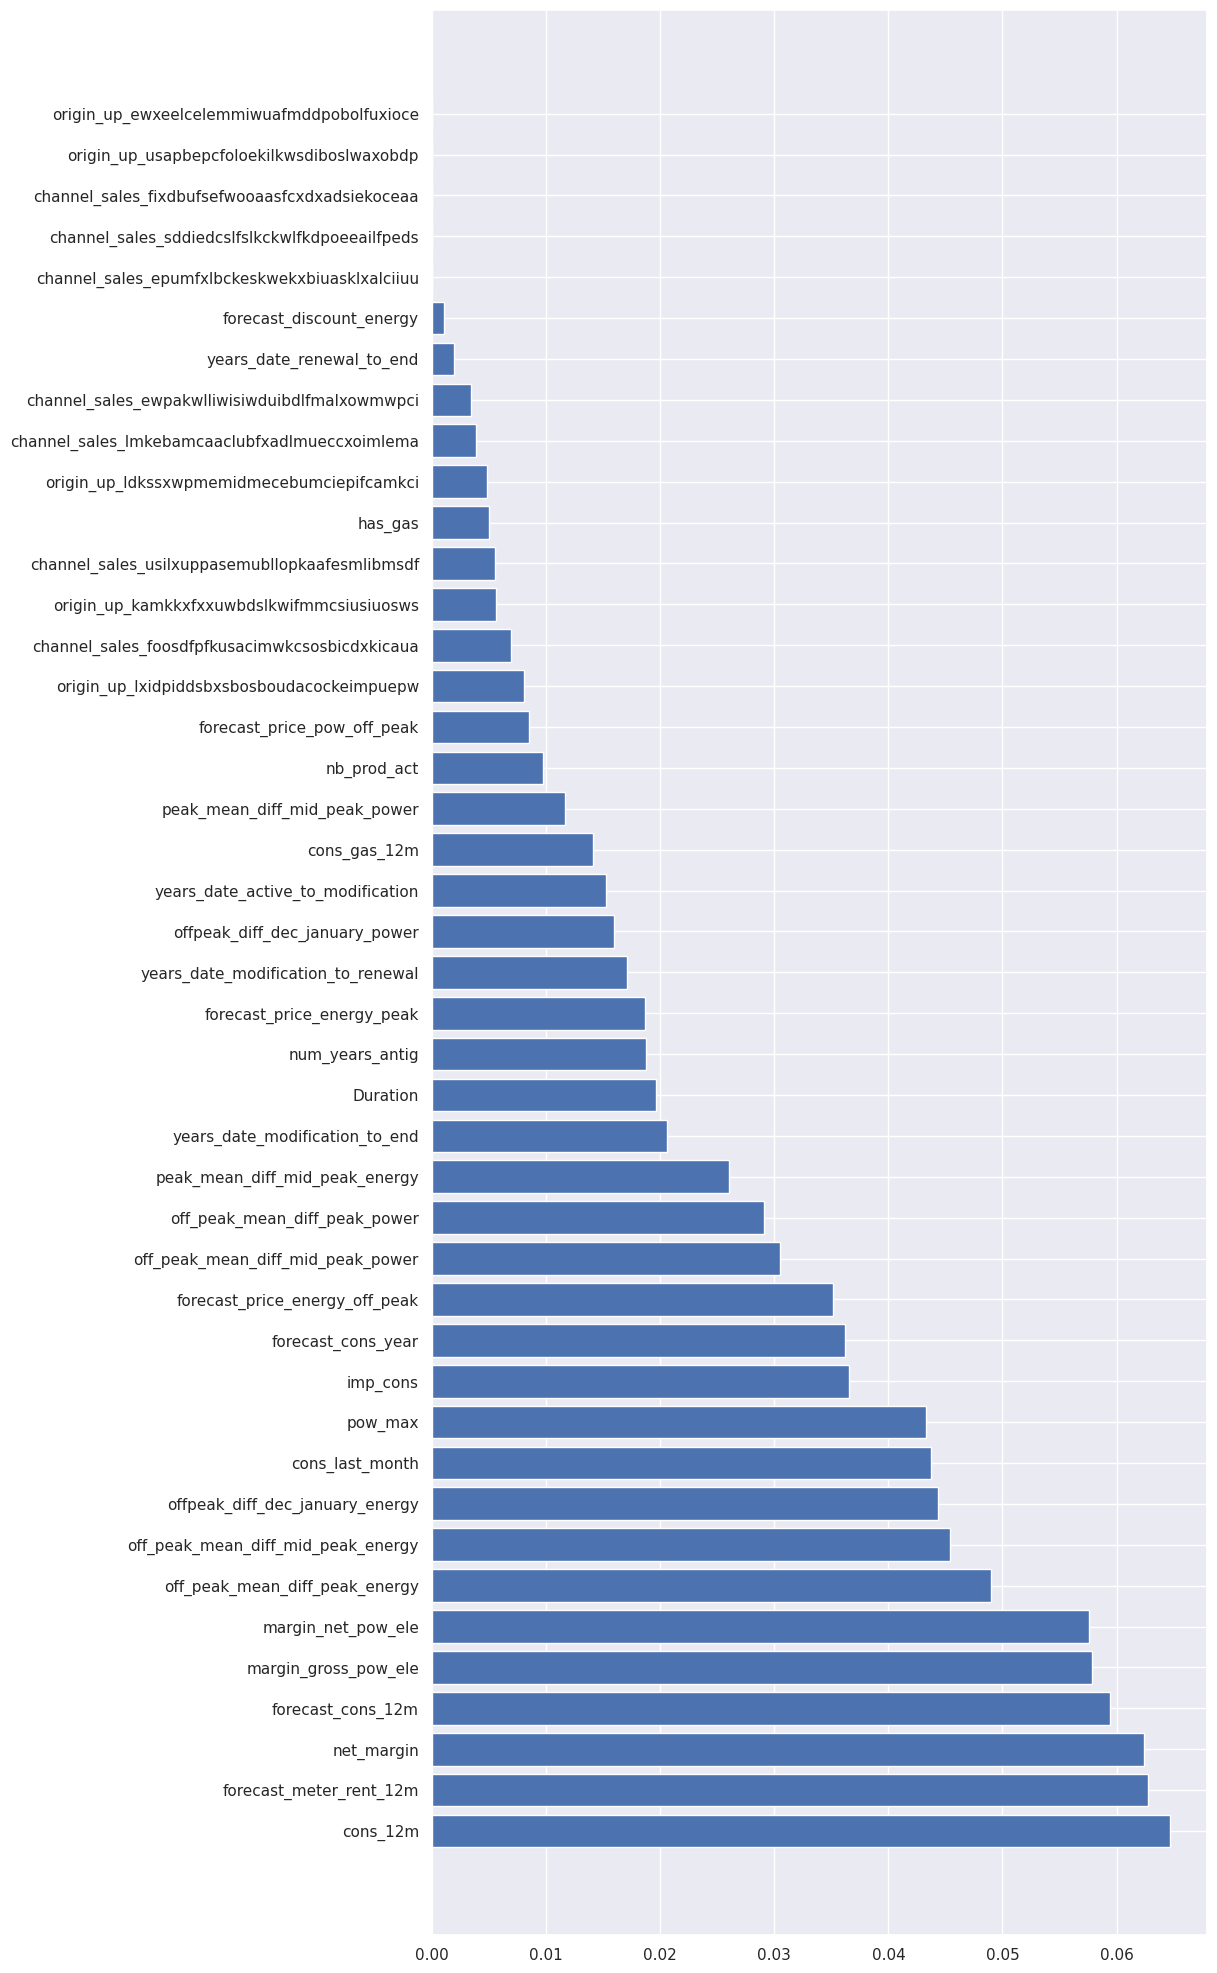

In [ ]:
plt.figure(figsize=(10, 25))
plt.barh(range(len(feature_importances)),feature_importances["importance"])
plt.yticks(range(len(feature_importances)),feature_importances["features"])
plt.plot()
plt.show()

Net margin and consumption over 12 months is a top driver for churn in this model.  

Margin on power subscription also is an influential driver.

Time seems to be an influential factor.

The difference in prices for off peak prices(energy) in january and december is in the top 10 in terms of how influential it is and some of the features built off the back of this actually outperform it.

Price sensitivity features are scattered around but are not the main driver for a customer churning.

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_2, X_train, y_train, n_repeats=10, random_state=42,n_jobs=-1)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(importance_df)

                                           feature  importance
12                            margin_gross_pow_ele    0.042703
13                              margin_net_pow_ele    0.040434
31      origin_up_lxidpiddsbxsbosboudacockeimpuepw    0.026966
6                          forecast_meter_rent_12m    0.024775
16                                 num_years_antig    0.020393
0                                         cons_12m    0.015610
20                                        Duration    0.013586
15                                      net_margin    0.011982
29      origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws    0.011532
17                                         pow_max    0.010348
3                                forecast_cons_12m    0.009448
18                 offpeak_diff_dec_january_energy    0.008382
37                  off_peak_mean_diff_peak_energy    0.007580
2                                  cons_last_month    0.006964
39              off_peak_mean_diff_mid_peak_energy    0

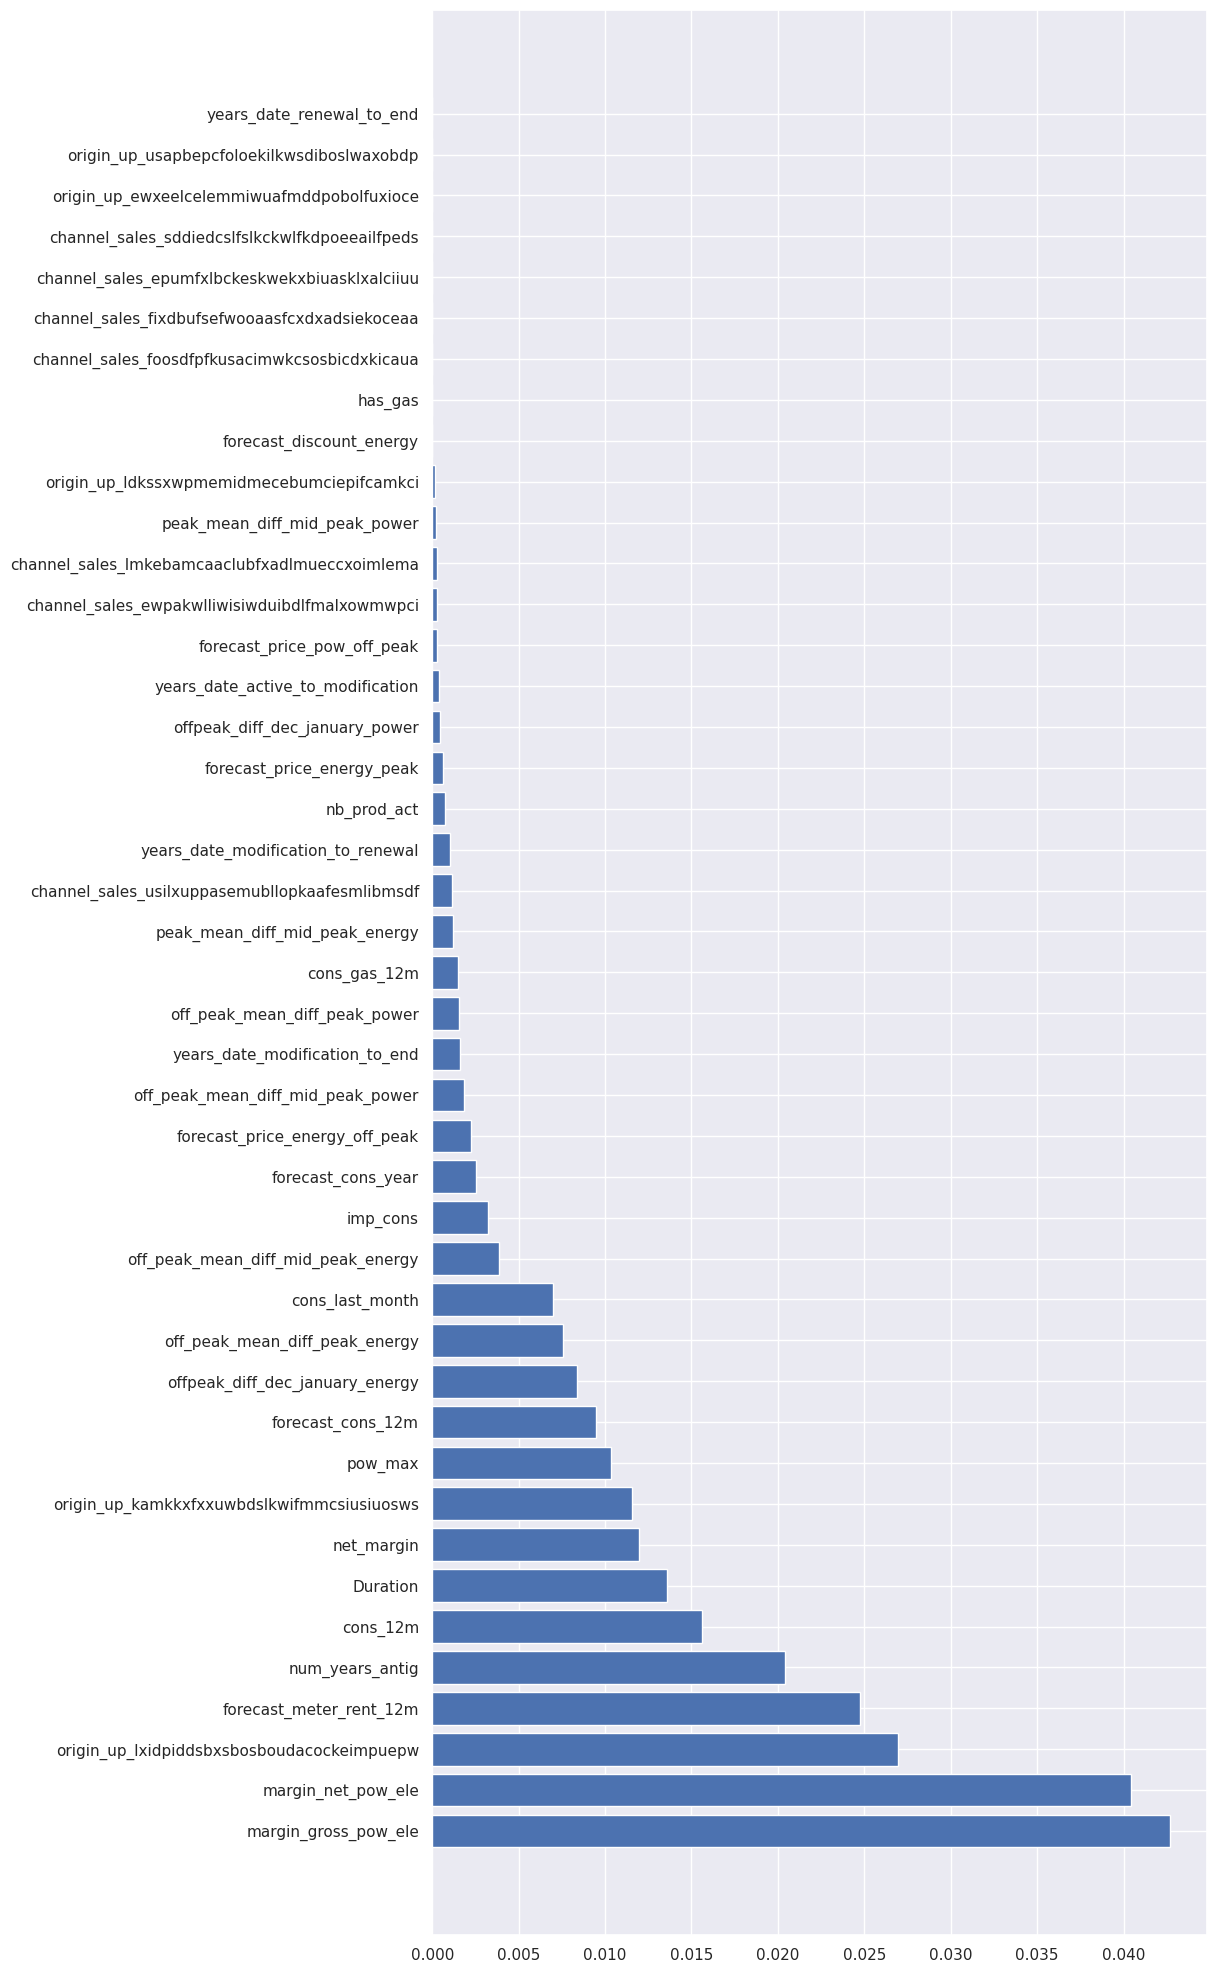

In [ ]:
plt.figure(figsize=(10, 25))
plt.barh(range(len(importance_df)),importance_df["importance"])
plt.yticks(range(len(importance_df)),importance_df["feature"])
plt.plot()
plt.show()

The permutation importance plot reveals that gross margins, net margins, consumption history, and duration are the most influential features in predicting customer churn.

 While certain price sensitivity features score high on feature importance, they rank low in permutation importance — suggesting that price sensitivity may not be a significant driver of churn.







# Strategic Recommendations

Based on the exploratory data analysis and churn prediction model, the following strategic recommendations are proposed to help PowerCo reduce customer churn and improve customer retention.

---

## 1. Target Newer Customers with Early Retention Programs

### Insight
The analysis revealed that customers with less than 5 years of tenure are significantly more likely to churn compared to long-term customers. This suggests that customer loyalty is not fully established during the initial years of the customer lifecycle.

### Recommendation
PowerCo should implement an **Early Life Customer Retention Program** focused on customers within their first 3–5 years of service.

### Suggested Actions
- Launch personalized onboarding and engagement campaigns.
- Provide regular usage insights and account reviews.
- Introduce loyalty rewards and retention incentives for newer customers.
- Conduct periodic satisfaction surveys to identify concerns early.


---

## 2. Create Churn Risk Alerts for Product Modification Events

### Insight
Customers who modified their products within the first 0–4 years after activation were found to have a higher likelihood of churning.

### Recommendation
PowerCo should treat product modification requests as potential churn signals and incorporate them into customer risk monitoring processes.

### Suggested Actions
- Automatically flag customers who request product modifications.
- Trigger customer follow-up communications after modifications are made.
- Monitor post-modification engagement and consumption patterns.
- Offer tailored support and product recommendations based on customer needs.



---



## 3. Investigate the Impact of Off-Peak Energy Price Changes

### Insight
The difference in off-peak energy prices between January and December emerged as an influential feature in the churn prediction model. While price sensitivity does not appear to be a primary driver of churn, changes in pricing may still affect customer perceptions and satisfaction.

### Recommendation
PowerCo should further investigate how pricing adjustments influence customer behavior and evaluate the effectiveness of pricing communication strategies.

### Suggested Actions
- Analyze customer responses following pricing changes.
- Improve transparency around tariff adjustments and pricing structures.
- Conduct customer feedback surveys regarding pricing perceptions.
- Identify customer segments that may be more sensitive to pricing changes.


---

# Conclusion

The analysis indicates that customer churn at PowerCo is primarily influenced by customer tenure, product modification behavior, profitability metrics, and consumption-related characteristics rather than pure price sensitivity. By implementing targeted retention strategies focused on newer customers, monitoring product modification events, prioritizing high-value customer segments, and further investigating pricing-related behaviors, PowerCo can proactively reduce churn and strengthen long-term customer relationships while maintaining profitability.

